# 4d. Feedforward Neural Network

**Project:** Predicting colorectal cancer screening non-compliance to guide targeted outreach
**Part of:** the modelling stage, split one notebook per model (`4a`-`4d`) so each model's fit,
results, and interpretation can be read, run, and re-run independently. All four write into the
same shared model registry (`data/processed/modelling/model_registry_manifest.csv`); the
cross-model comparison lives in `5 Evaluation.ipynb`, which reads that shared manifest rather than
refitting anything itself. (previous: `4c (Gradient Boosting)` | next: `5 (Evaluation)`)

**Inputs:** `crc_analytic_dataset.csv` (Data Preparation output), the split/technique artifacts
validated in `3 Data Processing.ipynb`, and the shared preprocessing components in
`pipeline_components.py`.

This notebook covers a fourth model beyond the three named in the proposal -- fit on M1/M2/M3, plus a cross-validated hyperparameter search. Every model notebook follows the same three-part structure --
**Model** (what's fit and how), **Results** (held-out test performance), **Analysis of factors**
(what's driving the predictions) -- so the four are easy to compare despite living in separate
files.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_DIR = PROCESSED_DIR / "modelling"
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

ANALYTIC_PATH = PROCESSED_DIR / "crc_analytic_dataset.csv"
SPLIT_PATH = MODEL_DIR / "train_calibration_test_split.csv"
for p in [ANALYTIC_PATH, SPLIT_PATH]:
    if not p.exists():
        raise FileNotFoundError(f"{p} not found. Run '3 Data Processing.ipynb' first.")

df = pd.read_csv(
    ANALYTIC_PATH,
    dtype={"respondent_id": "string", "state_fips": "string"},
    low_memory=False,
)
split_assignment = pd.read_csv(SPLIT_PATH, dtype={"respondent_id": "string"})
df = df.merge(split_assignment, on="respondent_id", validate="one_to_one")

assert df["split"].isna().sum() == 0
print("Loaded:", ANALYTIC_PATH)
print(df["split"].value_counts())

Loaded: ../data/processed/crc_analytic_dataset.csv
split
train          136588
test            45530
calibration     45529
Name: count, dtype: int64


In [2]:
import sys

sys.path.insert(0, str(Path.cwd()))
from pipeline_components import (
    RANDOM_SEED, M1_FEATURES, M2_FEATURES, M3_FEATURES,
    ORDINAL_FEATURES, NOMINAL_FEATURES, ORDINAL_CATEGORY_ORDER,
    OrdinalRankWithMissingFlag, ordinal_subset, nominal_subset,
    build_ffnn_pipeline, compute_classification_metrics, make_model_registry,
)

np.random.seed(RANDOM_SEED)
assert len(M1_FEATURES) == 8 and len(M2_FEATURES) == 12 and len(M3_FEATURES) == 17

X_train = df.loc[df["split"] == "train", M3_FEATURES]
y_train = df.loc[df["split"] == "train", "crc_noncompliant"]
X_cal = df.loc[df["split"] == "calibration", M3_FEATURES]
y_cal = df.loc[df["split"] == "calibration", "crc_noncompliant"]
X_test = df.loc[df["split"] == "test", M3_FEATURES]
y_test = df.loc[df["split"] == "test", "crc_noncompliant"]

for name, Xs, ys in [("train", X_train, y_train), ("calibration", X_cal, y_cal), ("test", X_test, y_test)]:
    print(f"{name:12s} n={len(Xs):>7,}   non-compliance rate={ys.mean():.4f}")

print("\nPipeline builder ready: build_ffnn_pipeline(features)")

train        n=136,588   non-compliance rate=0.2648
calibration  n= 45,529   non-compliance rate=0.2648
test         n= 45,530   non-compliance rate=0.2648

Pipeline builder ready: build_ffnn_pipeline(features)


In [3]:
MODELS_DIR = MODEL_DIR / "models"
MANIFEST_PATH = MODEL_DIR / "model_registry_manifest.csv"
MODEL_REGISTRY, register_model, load_registry = make_model_registry(MODELS_DIR, MANIFEST_PATH)

print("Model registry ready. Models will be saved under:", MODELS_DIR)
print("Comparison manifest (shared across 4a-4d) will be written to:", MANIFEST_PATH)

Model registry ready. Models will be saved under: ../data/processed/modelling/models
Comparison manifest (shared across 4a-4d) will be written to: ../data/processed/modelling/model_registry_manifest.csv


In [4]:
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.utils.class_weight import compute_sample_weight
import matplotlib.pyplot as plt

w_train = compute_sample_weight("balanced", y_train)

## Model

Fourth model, beyond the three named in the proposal -- a feedforward network (sklearn's
`MLPClassifier`) via `build_ffnn_pipeline` in `pipeline_components.py`. Fit on each of M1/M2/M3,
class-weighted via `sample_weight` for consistency with the other three models, registered into
the same `MODEL_REGISTRY`.

**Encoding differs from the two tree models and matches logistic regression instead:** a network
has no notion that an ordinal-encoded integer or a nominal category code should be split on a
threshold the way a tree can, so nominal predictors are one-hot encoded (not label-encoded) and
every input -- one-hot indicators and ordinal ranks alike -- is scaled with `StandardScaler`. An
unscaled mix of 0/1 indicators and larger-range ranks would let large-scale features dominate the
first layer's weights for reasons unrelated to predictive relevance.

**One thing worth checking rather than assuming:** support for `sample_weight` in
`MLPClassifier.fit` is not guaranteed across sklearn versions, and silently dropping class
weighting here would have been an easy way to get quietly worse minority-class performance
without an error to flag it. `pipeline_components.build_ffnn_pipeline` uses it directly, so no
oversampling workaround was needed, keeping this model consistent with the "class-weight, don't
oversample" approach used everywhere else.

Architecture: two hidden layers (64, 32 units), ReLU activation, `alpha=1e-4` L2 regularisation,
`early_stopping=True` (holds out 10% of the training fold internally to decide when to stop --
unrelated to, and untouched by, the calibration/test splits). These are reasonable defaults, not
a tuned configuration; the hyperparameter search below checks whether tuning them matters.

In [5]:
ffnn_rows = []
ffnn_test_probas = {}
for domain_name, features in [("M1", M1_FEATURES), ("M2", M2_FEATURES), ("M3", M3_FEATURES)]:
    pipe = build_ffnn_pipeline(features)
    pipe.fit(X_train[features], y_train, model__sample_weight=w_train)
    proba = pipe.predict_proba(X_test[features])[:, 1]
    metrics = compute_classification_metrics(y_test, proba)
    ffnn_rows.append({"Model": domain_name, "N predictors": len(features), **metrics})
    ffnn_test_probas[domain_name] = proba
    register_model(
        name=f"ffnn_{domain_name}", pipeline=pipe, metrics=metrics, features=features,
        model_type="Feedforward Neural Network (class-weighted, MLPClassifier, hidden=(64,32))",
        notes="early_stopping=True; sample_weight supported natively by MLPClassifier.fit in this sklearn version.",
    )

ffnn_table = pd.DataFrame(ffnn_rows)
ffnn_table.to_csv(MODEL_DIR / "ffnn_results.csv", index=False)
ffnn_table.round(3)

,Model,N predictors,AUROC,AUPRC,Precision,Sensitivity,Specificity,F1,Accuracy
0,M1,8,0.718,0.495,0.438,0.602,0.722,0.507,0.690
1,M2,12,0.761,0.590,0.494,0.624,0.769,0.551,0.731
2,M3,17,0.762,0.589,0.494,0.623,0.770,0.551,0.731


## Results

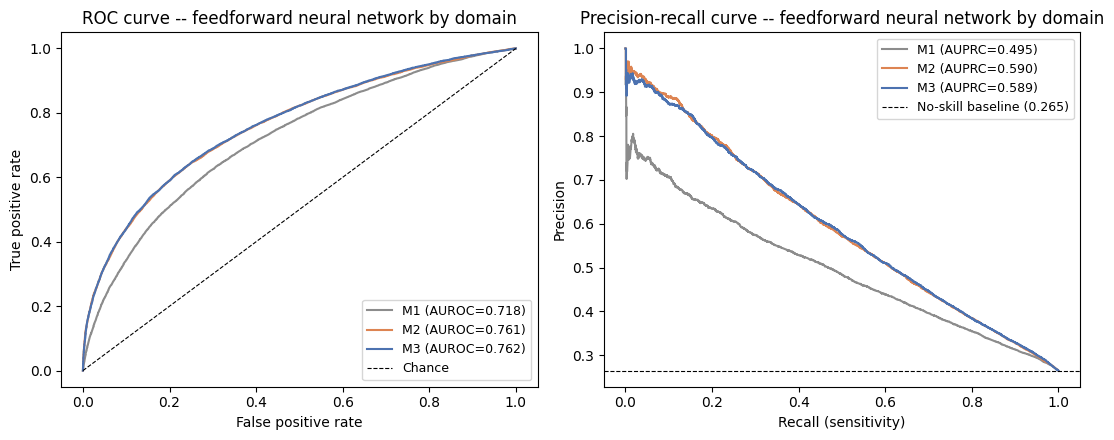

In [6]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
colors = {"M1": "#8C8C8C", "M2": "#DD8452", "M3": "#4C72B0"}

for domain_name in ["M1", "M2", "M3"]:
    proba = ffnn_test_probas[domain_name]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auroc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, color=colors[domain_name], label=f"{domain_name} (AUROC={auroc:.3f})")

    precision, recall, _ = precision_recall_curve(y_test, proba)
    auprc = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, color=colors[domain_name], label=f"{domain_name} (AUPRC={auprc:.3f})")

axes[0].plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=0.8, label="Chance")
axes[0].set_xlabel("False positive rate")
axes[0].set_ylabel("True positive rate")
axes[0].set_title("ROC curve -- feedforward neural network by domain")
axes[0].legend(loc="lower right", fontsize=9)

axes[1].axhline(y_test.mean(), linestyle="--", color="black", linewidth=0.8,
                label=f"No-skill baseline ({y_test.mean():.3f})")
axes[1].set_xlabel("Recall (sensitivity)")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-recall curve -- feedforward neural network by domain")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig18_ffnn_roc_pr_curves.png", dpi=150)
plt.show()

## Analysis of factors

A network's weights don't reduce to per-predictor coefficients the way a linear model's do --
even with one hidden layer, a feature's effect is mediated through every hidden unit it feeds
into, so "the weight on this input" isn't a meaningful summary the way an odds ratio is. Same
approach as the two tree models, for comparability: permutation importance on the fitted M3
pipeline, computed on a random 15,000-row test subsample with 5 repeats per feature.

In [7]:
from sklearn.inspection import permutation_importance

ffnn_m3_pipeline = MODEL_REGISTRY["ffnn_M3"]["pipeline"]

rng = np.random.RandomState(RANDOM_SEED)
perm_sample_idx = rng.choice(X_test.index, size=15_000, replace=False)

perm_result = permutation_importance(
    ffnn_m3_pipeline, X_test.loc[perm_sample_idx, M3_FEATURES], y_test.loc[perm_sample_idx],
    n_repeats=5, random_state=RANDOM_SEED, scoring="roc_auc", n_jobs=1,  # n_jobs=1, not -1: permutation_importance with multiprocessing pickles the whole fitted pipeline + data per worker, which has been reported to raise a MemoryError/PicklingError on some Windows setups (joblib's loky backend) -- single-process is slower but reliable everywhere.
)

ffnn_perm_importance_table = pd.DataFrame({
    "feature": M3_FEATURES,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std,
}).sort_values("importance_mean", ascending=False)
ffnn_perm_importance_table.to_csv(MODEL_DIR / "ffnn_permutation_importance.csv", index=False)
ffnn_perm_importance_table.round(4)

,feature,importance_mean,importance_std
0,age_group,0.0706,0.0030
11,checkup_recency,0.0414,0.0010
5,employment_status,0.0106,0.0017
4,income_group,0.0093,0.0007
9,personal_doctor,0.0086,0.0007
3,education_level,0.0083,0.0013
6,marital_status,0.0052,0.0004
2,race_ethnicity,0.0037,0.0006
8,insurance_status,0.0033,0.0010
15,smoking_status,0.0028,0.0005


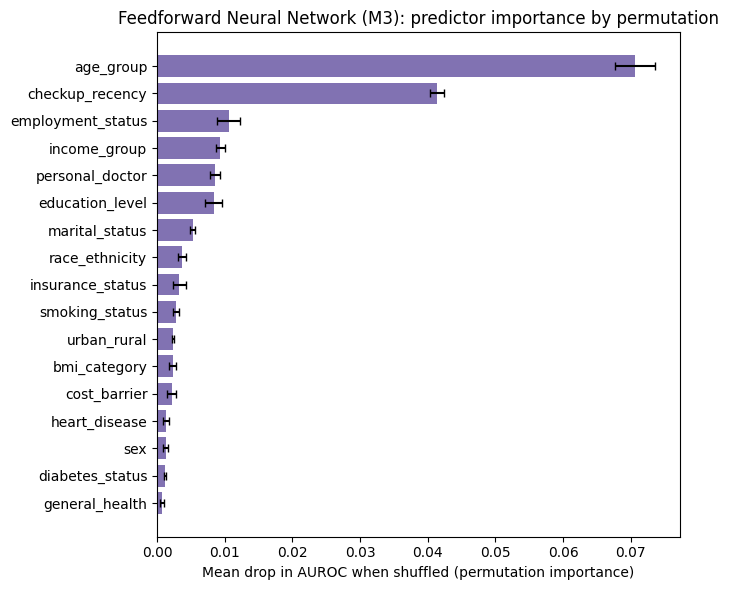

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
plot_order = ffnn_perm_importance_table.sort_values("importance_mean")
ax.barh(
    plot_order["feature"], plot_order["importance_mean"],
    xerr=plot_order["importance_std"], color="#8172B2", capsize=3,
)
ax.set_xlabel("Mean drop in AUROC when shuffled (permutation importance)")
ax.set_title("Feedforward Neural Network (M3): predictor importance by permutation")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig19_ffnn_permutation_importance.png", dpi=150)
plt.show()

**Reading the chart:** the same two predictors lead as in both tree models -- `age_group`
(~0.071 mean AUROC drop) and `checkup_recency` (~0.041) -- with `employment_status`,
`income_group`, `personal_doctor` and `education_level` forming a consistent secondary tier. All
three non-linear models (random forest, gradient boosting, feedforward network) agree on this
ranking far more than any of them agrees with the logistic regression odds ratios on relative
magnitude, which is the same age-gradient story discussed above: a model that can represent
non-linear relationships directly picks up on `age_group`'s importance in a way one linear
coefficient can't.

### Hyperparameter search

Same pattern as the two tree models' searches: `RandomizedSearchCV`, 10 parameter combinations,
3-fold stratified CV, scored on AUROC, run on the same 40,000-row training subsample for runtime
reasons. Search space covers network capacity (`hidden_layer_sizes`, from a single 32-unit layer
up to a three-layer 100-50-25 network), `alpha` (L2 regularisation), `learning_rate_init`, and
`activation` (`relu` vs `tanh`) -- the parameters most likely to trade off underfitting against
overfitting for a network this size. Done within the training fold only, consistent with the
calibration-vs-validation distinction from notebook 3.

In [9]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

search_sample_idx = np.random.RandomState(RANDOM_SEED).choice(X_train.index, size=40_000, replace=False)
X_search = X_train.loc[search_sample_idx, M3_FEATURES]
y_search = y_train.loc[search_sample_idx]
w_search = compute_sample_weight("balanced", y_search)

ffnn_search_pipe = build_ffnn_pipeline(M3_FEATURES)
ffnn_param_distributions = {
    "model__hidden_layer_sizes": [(32,), (64,), (64, 32), (128, 64), (100, 50, 25)],
    "model__alpha": [1e-5, 1e-4, 1e-3, 1e-2],
    "model__learning_rate_init": [1e-4, 1e-3, 1e-2],
    "model__activation": ["relu", "tanh"],
}

ffnn_search = RandomizedSearchCV(
    ffnn_search_pipe, ffnn_param_distributions, n_iter=10,
    cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_SEED),
    scoring="roc_auc", random_state=RANDOM_SEED, n_jobs=1,
)
ffnn_search.fit(X_search, y_search, model__sample_weight=w_search)

print("Best parameters found:", ffnn_search.best_params_)
print(f"Best CV AUROC (on the 40k search subsample): {ffnn_search.best_score_:.4f}")

Best parameters found: {'model__learning_rate_init': 0.01, 'model__hidden_layer_sizes': (128, 64), 'model__alpha': 0.0001, 'model__activation': 'relu'}
Best CV AUROC (on the 40k search subsample): 0.7540


In [10]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier

best_ffnn_params = {
    k.replace("model__", ""): v for k, v in ffnn_search.best_params_.items()
}

ffnn_tuned_pipe = Pipeline([
    ("preprocess", ColumnTransformer([
        ("ordinal", OrdinalRankWithMissingFlag(
            {c: ORDINAL_CATEGORY_ORDER[c] for c in ordinal_subset(M3_FEATURES)}
        ), ordinal_subset(M3_FEATURES)),
        ("nominal", OneHotEncoder(handle_unknown="ignore"), nominal_subset(M3_FEATURES)),
    ])),
    ("scale", StandardScaler(with_mean=False)),
    ("model", MLPClassifier(
        early_stopping=True, random_state=RANDOM_SEED, **best_ffnn_params,
    )),
])
ffnn_tuned_pipe.fit(X_train[M3_FEATURES], y_train, model__sample_weight=w_train)

proba_ffnn_tuned = ffnn_tuned_pipe.predict_proba(X_test[M3_FEATURES])[:, 1]
ffnn_tuned_metrics = compute_classification_metrics(y_test, proba_ffnn_tuned)

register_model(
    name="ffnn_M3_tuned", pipeline=ffnn_tuned_pipe, metrics=ffnn_tuned_metrics, features=M3_FEATURES,
    model_type="Feedforward Neural Network (class-weighted, RandomizedSearchCV-tuned)",
    notes=(f"{best_ffnn_params} -- from a 10-iter/cv=3 RandomizedSearchCV on a 40k-row training subsample."),
)

ffnn_comparison = pd.DataFrame([
    {"Model": "ffnn_M3 (default)", **MODEL_REGISTRY["ffnn_M3"]["metrics"]},
    {"Model": "ffnn_M3_tuned (searched)", **ffnn_tuned_metrics},
])
ffnn_comparison.round(4)

,Model,AUROC,AUPRC,Precision,Sensitivity,Specificity,F1,Accuracy
0,ffnn_M3 (default),0.7623,0.5893,0.4941,0.6231,0.7703,0.5512,0.7313
1,ffnn_M3_tuned (searched),0.7638,0.5910,0.4706,0.6661,0.7302,0.5516,0.7132


**Reading this comparison:** the search preferred a larger network (128, 64 hidden units, vs.
the 64, 32 default) with a higher learning rate (0.01 vs. the default 0.001) and the same ReLU
activation and light L2 regularisation. Test AUROC improves modestly, 0.7623 -> 0.7638 -- the
same small-but-real "tuning helps a little" pattern seen with gradient boosting, and larger than
random forest's near-tie. Worth flagging rather than glossing over: the tuned model's precision
drops (0.494 -> 0.471) while sensitivity rises noticeably (0.623 -> 0.666) at the default 0.5
threshold -- a real precision/recall trade-off from the larger, higher-learning-rate network, not
just noise, and a reminder that "AUROC went up" doesn't automatically mean every operating-point
metric moves the same direction. `ffnn_M3_tuned` is registered alongside everything else and
included in the model comparison below.